**Unsupervised Learning - Clustering**

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/features_selected_rfe.csv')
df.head()

,thal,cp,ca,thalach,oldpeak,age,chol,trestbps,exang,slope,num
0,0.660004,-2.251775,-0.711131,0.017197,1.087338,0.948726,-0.264900,0.757525,-0.696631,2.274579,0
1,-0.890238,0.877985,2.504881,-1.821905,0.397182,1.392002,0.760415,1.611220,1.435481,0.649113,1
2,1.176752,0.877985,1.432877,-0.902354,1.346147,1.392002,-0.342283,-0.665300,1.435481,0.649113,1
3,-0.890238,-0.165268,-0.711131,1.637359,2.122573,-1.932564,0.063974,-0.096170,-0.696631,2.274579,0
4,-0.890238,-1.208521,-0.711131,0.980537,0.310912,-1.489288,-0.825922,-0.096170,-0.696631,-0.976352,0


K-Means Clustering

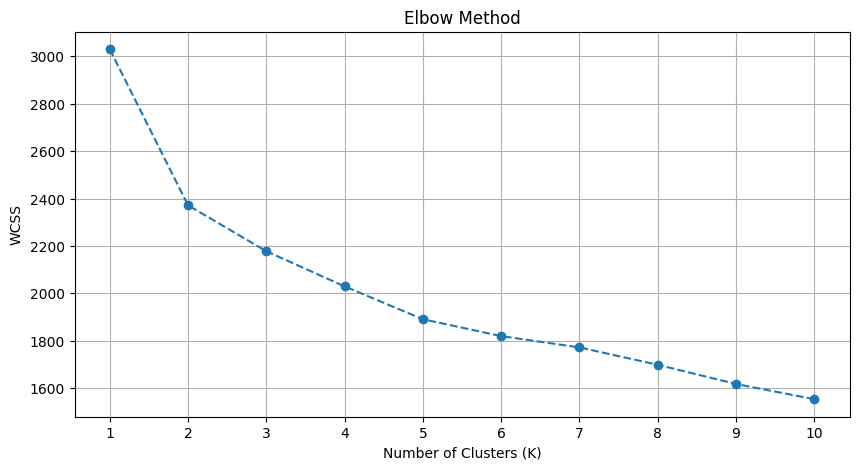

In [4]:
X = df.drop('num', axis=1)
y = df['num']

# Use the elbow method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [6]:
# Apply K-Means clustering with K=2
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(X)

# Get the cluster labels
cluster_labels = kmeans.labels_

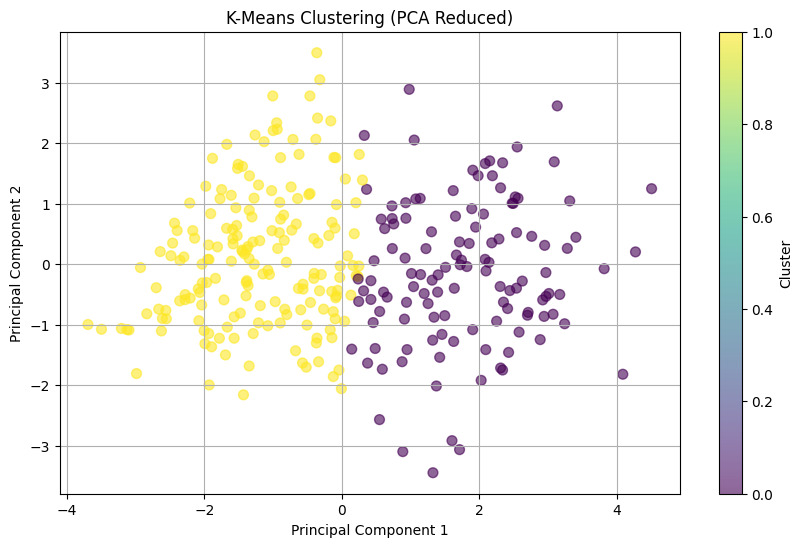

In [7]:
from sklearn.decomposition import PCA

# Reduce the dimensionality of the data for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a scatter plot of the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o', s=50, alpha=0.6)
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

Hierarchical Clustering

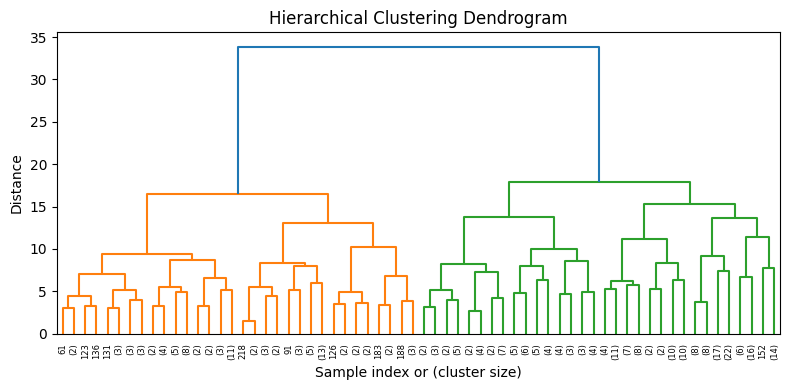

In [9]:
Z = sch.linkage(X, method='ward')
plt.figure(figsize=(8, 4))
sch.dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

Compare clusters with actual disease labels

Adjusted Rand Index (ARI): 0.38698166881420243
Normalized Mutual Information (NMI): 0.3043871194885883


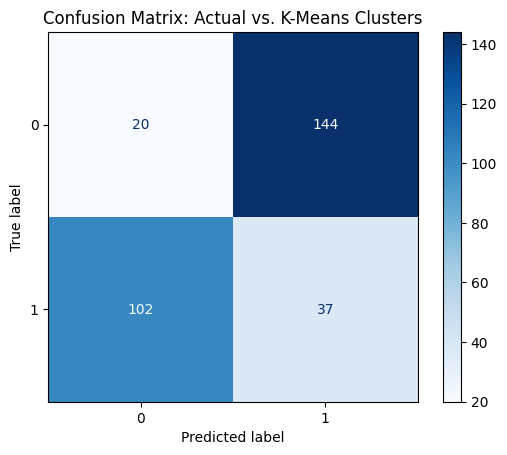

In [10]:
# Compare K-Means clusters with actual disease labels
print("Adjusted Rand Index (ARI):", adjusted_rand_score(y, cluster_labels))
print("Normalized Mutual Information (NMI):", normalized_mutual_info_score(y, cluster_labels))

# Create a confusion matrix
cm = confusion_matrix(y, cluster_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Actual vs. K-Means Clusters')
plt.show()